# 0. Import, device and hyper-parameters

In [1]:
import utils
import torch
import torch.nn as nn
import torch.nn.functional as F
import os


device = utils.try_gpu(0)
print(f"Use the {device} device")

bos_token = 1
eos_token = 2
DATA_PATH = "./data/cmn-eng/cmn.txt"

# 面向完整 cmn-eng（~3.2 万句）；5090 显存充裕
# num_steps=32 可覆盖约 99% 英/中序列（含 bos/eos）
embed_size, num_hiddens, num_layers, dropout = 256, 256, 2, 0.1
batch_size, num_steps = 256, 32
lr, num_epochs = 0.001, 1000



Use the cuda:0 device


# 1. Data loading and pre-processing

### 数据与训练工具（已迁入 `utils.py`）

| 功能 | 推荐名 | 旧别名 |
|---|---|---|
| 读 cmn.txt | `utils.load_data_cmn_eng` | `load_data_TdBSP` |
| 建词表+索引 | `utils.preprocess_nmt` | `preprocess_data` |
| DataLoader | `utils.data_loader_nmt` | `data_loader_TdBSP` |
| pad/截断 | `utils.truncate_pad` / `build_array_nmt` | — |
| mask / loss | `utils.sequence_mask` / `MaskedSoftmaxCELoss` | `seq_mask` |
| 外壳 / 训练 / 翻译 | `EncoderDecoder` / `train_seq2seq` / `translate_seq2seq` | `translate` |


数据加载 / 预处理 / DataLoader 见 `utils`：
- `utils.load_data_cmn_eng`（别名 `load_data_TdBSP`）
- `utils.preprocess_nmt`（别名 `preprocess_data`）
- `utils.data_loader_nmt`（别名 `data_loader_TdBSP`）


In [2]:
load_data_TdBSP = utils.load_data_TdBSP
preprocess_data = utils.preprocess_data
data_loader_TdBSP = utils.data_loader_TdBSP


In [3]:
Xs, Ys = load_data_TdBSP(DATA_PATH)
X, Y, X_vocab, Y_vocab = preprocess_data(Xs, Ys)

print(f"The first 5 words in the source sequence: \n{Xs[:5]}")
print(f"The first 5 words in the target sequence: \n{Ys[:5]}")
print(f"The vocabulary size of source sequence: {len(X_vocab)}, The first 10 words in the vocabulary: \n{X_vocab.idx_to_token[:10]}")
print(f"The vocabulary size of target sequence: {len(Y_vocab)}, The first 10 words in the vocabulary: \n{Y_vocab.idx_to_token[:10]}")

train_iter = data_loader_TdBSP(X, Y, batch_size, num_steps)



The first 5 words in the source sequence: 
[['Hi', '<eos>'], ['Hi', '<eos>'], ['Run', '<eos>'], ['Who', '<eos>'], ['Fire', '<eos>']]
The first 5 words in the target sequence: 
[['嗨', '<eos>'], ['你', '好', '<eos>'], ['你', '用', '跑', '的', '<eos>'], ['誰', '<eos>'], ['火', '<eos>']]
The vocabulary size of source sequence: 9551, The first 10 words in the vocabulary: 
['<unk>', '<bos>', '<eos>', 'I', 'to', 'the', 'you', 'a', 'is', 'Tom']
The vocabulary size of target sequence: 3726, The first 10 words in the vocabulary: 
['<unk>', '<bos>', '<eos>', '我', '的', '了', '你', '他', '不', '是']


# 2. Model and function

In [4]:
class Seq2SeqEncoder(nn.Module):
    """用于序列到序列学习的循环神经网络编码器。"""
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers,
                 dropout=0, **kwargs):
        super(Seq2SeqEncoder, self).__init__(**kwargs)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size, num_hiddens, num_layers, dropout=dropout)
    
    def forward(self, X, *args):
        # Input size: (batch_size, seq_len)
        X = self.embedding(X)  # (batch_size, seq_len, embed_size)
        X = X.permute(1, 0, 2)  # (seq_len, batch_size, embed_size)
        output, state = self.rnn(X)
        # output size: (seq_len, batch_size, num_hiddens)
        # state size: (num_layers, batch_size, num_hiddens)
        return output, state

In [5]:
from multiprocessing import context


class Seq2SeqDecoder(nn.Module):
    """用于序列到序列学习的循环神经网络解码器。"""
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers,
                 dropout=0, **kwargs):
        super(Seq2SeqDecoder, self).__init__(**kwargs)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size + num_hiddens, num_hiddens, num_layers,
                          dropout=dropout)
        self.dense = nn.Linear(num_hiddens, vocab_size)
    
    def init_state(self, enc_outputs, *args):
        return enc_outputs[1]
    
    def forward(self, X, state):
        # Input size: (batch_size, seq_len)
        X = self.embedding(X) # (batch_size, seq_len, embed_size)
        X = X.permute(1, 0, 2) # (seq_len, batch_size, embed_size)
        context = state[-1].repeat(X.shape[0], 1, 1)
        X_and_context = torch.cat((X, context), dim=2)
        output, state = self.rnn(X_and_context, state)
        output = self.dense(output).permute(1, 0, 2)
        return output, state

In [6]:
seq_mask = utils.seq_mask
sequence_mask = utils.sequence_mask
MaskedSoftmaxCELoss = utils.MaskedSoftmaxCELoss


`seq_mask` / `MaskedSoftmaxCELoss` / `train_seq2seq` / `EncoderDecoder` / `translate` 已迁入 `utils.py`。


In [7]:
train_seq2seq = utils.train_seq2seq
EncoderDecoder = utils.EncoderDecoder
translate = utils.translate


通用外壳：`utils.EncoderDecoder`。
章节模型 `Seq2SeqEncoder` / `Seq2SeqDecoder` 仍保留在本 notebook（上方 cells）。


In [8]:
encoder = Seq2SeqEncoder(len(X_vocab), embed_size, num_hiddens, num_layers, dropout)
decoder = Seq2SeqDecoder(len(Y_vocab), embed_size, num_hiddens, num_layers, dropout)
net = EncoderDecoder(encoder, decoder)

# Training and generation

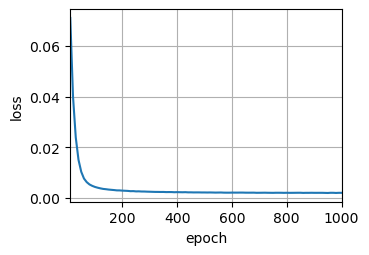

loss 0.002, 161458.9 tokens/sec on cuda:0


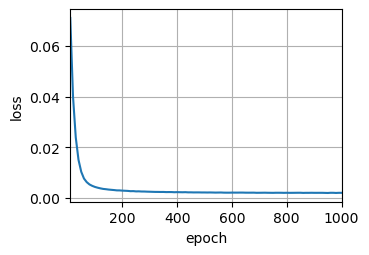

In [9]:
train_seq2seq(net, train_iter, lr, num_epochs, Y_vocab, device)

In [10]:
# 英->中示例：src 按词、tgt 无分隔拼接
translate(net, "Hi.", X_vocab, Y_vocab, num_steps, device)
# 等价于 utils.translate_seq2seq(..., src_tokenize="word", tgt_join="")


'嗨！你不要是出反复'

In [11]:
print(translate(net, "I won!", X_vocab, Y_vocab, num_steps, device))
print(translate(net, "Hello!", X_vocab, Y_vocab, num_steps, device))


我赢了
你好好就拿出笑一个人想道歉
